In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
import qutip as qt
import numpy as np
from jaxcurveimpls import BezierCurve
from scipy.linalg import expm

In [2]:
key = jax.random.key(44062)
curve = BezierCurve(32, [0, 0, 0], key)

curve : BezierCurve = eqx.tree_deserialise_leaves('bezier.eqx', curve)

ERROR:2026-03-29 23:38:07,701:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/bobby/CS/quantum/.venv/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/bobby/CS/quantum/.venv/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bobby/CS/quantum/.venv/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


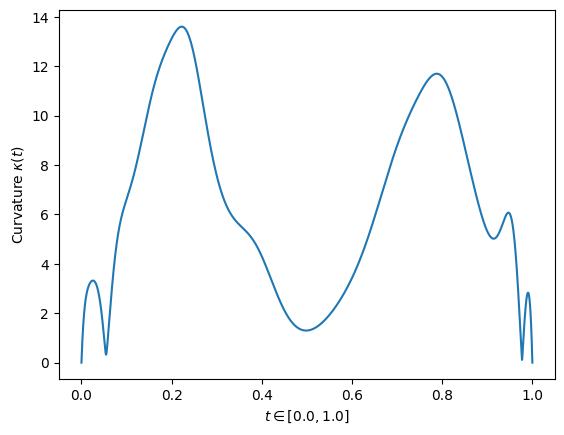

In [3]:
curve.plot_curvature()

In [4]:
def make_system_H(alpha=1.0, beta=0.7):
    return alpha * qt.sigmaz() + beta * qt.sigmax()

def unitary_from_piecewise_omega(H_sys, omega, dt):
    """
    omega: array of length N (piecewise constant amplitudes)
    dt: time step
    Returns:
        U (Qobj): joint unitary on system⊗ancilla for the interaction-picture dynamics
    """
    N = len(omega)
    tlist = np.arange(N+1) * dt  # N intervals, N+1 points

    # Precompute phi at the grid points (left Riemann sum for simplicity)
    phi = np.zeros(N+1)
    for k in range(N):
        phi[k+1] = phi[k] + omega[k] * dt

    # Operators
    Hy = qt.tensor(H_sys, qt.sigmay())
    Hz = qt.tensor(H_sys, qt.sigmaz())

    # Build coefficient arrays on the same grid expected by mesolve for "array coefficients"
    # We'll use values on tlist (length N+1). QuTiP will interpolate between them.
    cz = np.cos(2.0 * phi)
    cy = np.sin(2.0 * phi)

    H_td = [
        [Hz, cz],
        [Hy, cy],
    ]

    # Propagate unitary by evolving basis states (dimension d) or use propagator
    U = qt.propagator(H_td, tlist[-1], tlist=tlist)  # Qobj unitary on joint space
    return U


In [5]:
values = np.asarray(jax.vmap(curve.curvature)( jnp.linspace( curve.t0, curve.tf, 8192 ) ))
dt = np.asarray( curve.arclength(8192) ) / 8192

m1 = np.asarray( curve.position(1) - curve.position(0) )[-1]
m2 = np.asarray( curve.magnus(2, key, 8192) )[-1]
m3 = np.asarray( curve.magnus(3, key, 8192) )[-1]
m4 = np.asarray( curve.magnus(4, key, 8192) )[-1]

hamiltonian = make_system_H( *np.random.uniform(0, 0.5, 2) )


print( "Max curvature:", values.max() )
print( "dt:", dt)

print( "Magnus 1:", m1 )
print( "Magnus 2:", m2 )
print( "Magnus 3:", m3 )
print( "Magnus 4:", m4 )

print(hamiltonian)

Max curvature: 13.608333
dt: 0.00015850332
Magnus 1: 0.0
Magnus 2: -0.16995353
Magnus 3: -0.0003379863
Magnus 4: 0.008653739
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.45156919  0.37412043]
 [ 0.37412043 -0.45156919]]


In [6]:
unitary = unitary_from_piecewise_omega( hamiltonian, values / 2, dt )

print(unitary)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 9.98103595e-01-1.39561077e-02j  1.67508502e-02-5.46570247e-02j
  -1.16814935e-18-1.15624916e-02j  1.38779071e-02-4.94360242e-19j]
 [-1.67508502e-02-5.46570247e-02j  9.98103595e-01+1.39561077e-02j
  -1.38779071e-02-4.94360242e-19j -1.16814935e-18+1.15624916e-02j]
 [ 1.16814935e-18-1.15624916e-02j  1.38779071e-02+4.94360242e-19j
   9.98103595e-01+1.39561077e-02j -1.67508502e-02-5.46570247e-02j]
 [-1.38779071e-02+4.94360242e-19j  1.16814935e-18+1.15624916e-02j
   1.67508502e-02-5.46570247e-02j  9.98103595e-01-1.39561077e-02j]]


In [7]:
Z = np.array([[1, 0], [-1, 0]], dtype=np.complex64)
H = np.asarray( hamiltonian.full() )

print(H)

[[ 0.45156919+0.j  0.37412043+0.j]
 [ 0.37412043+0.j -0.45156919+0.j]]


### Sinc taylor series

$$
f(H) = I - \frac{H^2}{6} + \frac{H^4}{120}
$$

with complex terms

$$
f(H) = I - i\frac{H^2}{6} - i\frac{H^4}{120}
$$


In [8]:

h_two = np.linalg.matrix_power(H, 2)
h_four = np.linalg.matrix_power(H, 4)

expected = expm( -1j * np.kron( np.eye(2) - 1j * h_two / 6 - 1j * h_four / 120 , Z ) )

print(expected)

[[ 5.09703858e-01-7.93816726e-01j  0.00000000e+00+0.00000000e+00j
  -4.38464354e-19+6.82867772e-19j  0.00000000e+00+0.00000000e+00j]
 [ 4.90296142e-01+7.93816726e-01j  1.00000000e+00+0.00000000e+00j
   4.38464354e-19-6.82867772e-19j  0.00000000e+00+0.00000000e+00j]
 [-4.38464354e-19+6.82867772e-19j  0.00000000e+00+0.00000000e+00j
   5.09703858e-01-7.93816726e-01j  0.00000000e+00+0.00000000e+00j]
 [ 4.38464354e-19-6.82867772e-19j  0.00000000e+00+0.00000000e+00j
   4.90296142e-01+7.93816726e-01j  1.00000000e+00+0.00000000e+00j]]


In [ ]:
print( np.linalg.matrix_norm( expected - np.asarray(unitary.full()), ord=2 ) )

TypeError: matrix_norm() takes 1 positional argument but 2 were given